# QM8 Full Benchmark (3 Seeds)

This notebook benchmarks classical, uni-modal, bi-modal, tri-modal, and tri-modal fusion models on QM8 in multi-task regression setup with three random seeds.

Compared model families include RF (RDKit), task-wise ChebNet, SEG, TAME, and TAME-Fusion, each with vanilla and stage-1-pretrained variants where applicable.

## Setup
- Dataset: QM8 (16-task quantum-mechanical regression, DeepChem MolNet)
- Split: DeepChem random split (predefined train/valid/test)
- Seeds: `[11, 22, 33]`
- Metric report: Macro MAE, Macro RMSE, Macro Pearson r (original target scale)

In [1]:
import sys
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import deepchem as dc

from sklearn.ensemble import RandomForestRegressor

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig
from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def apply_inverse_transform(y, transformers):
    arr = np.asarray(y, dtype=np.float32)
    if transformers is None:
        return arr
    for t in reversed(transformers):
        arr = t.untransform(arr)
    return np.asarray(arr, dtype=np.float32)

def multitask_regression_metrics(y_true_norm, y_pred_norm, transformers=None, weights=None):
    yt = np.asarray(y_true_norm, dtype=np.float32)
    yp = np.asarray(y_pred_norm, dtype=np.float32)

    if yt.ndim != 2 or yp.ndim != 2 or yt.shape != yp.shape:
        raise ValueError('y_true_norm and y_pred_norm must be 2D arrays of same shape')

    yt_raw = apply_inverse_transform(yt, transformers)
    yp_raw = apply_inverse_transform(yp, transformers)

    if weights is None:
        obs = np.isfinite(yt_raw) & np.isfinite(yp_raw)
    else:
        w = np.asarray(weights, dtype=np.float32)
        if w.ndim != 2 or w.shape != yt_raw.shape:
            raise ValueError('weights must be same 2D shape as labels')
        obs = (w > 0) & np.isfinite(yt_raw) & np.isfinite(yp_raw)

    n_tasks = yt_raw.shape[1]
    maes, rmses, pears, n_obs = [], [], [], []
    for t in range(n_tasks):
        mask_t = obs[:, t]
        n_t = int(mask_t.sum())
        if n_t == 0:
            maes.append(np.nan)
            rmses.append(np.nan)
            pears.append(np.nan)
            n_obs.append(0)
            continue

        yt_t = yt_raw[mask_t, t]
        yp_t = yp_raw[mask_t, t]
        err = yp_t - yt_t

        mae_t = float(np.mean(np.abs(err)))
        rmse_t = float(np.sqrt(np.mean(err * err)))
        if yt_t.size > 1 and np.std(yt_t) > 0 and np.std(yp_t) > 0:
            pear_t = float(np.corrcoef(yt_t, yp_t)[0, 1])
        else:
            pear_t = np.nan

        maes.append(mae_t)
        rmses.append(rmse_t)
        pears.append(pear_t)
        n_obs.append(n_t)

    return {
        'macro_mae': float(np.nanmean(maes)) if len(maes) else np.nan,
        'macro_rmse': float(np.nanmean(rmses)) if len(rmses) else np.nan,
        'macro_pearson': float(np.nanmean(pears)) if len(pears) else np.nan,
        'n_tasks_eval': int(np.sum(np.asarray(n_obs) > 0)),
        'n_points_eval': int(np.sum(n_obs)),
    }

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

@contextmanager
def patch_build_model_with_encoder_init(predictor, encoder_state, strict=True):
    original_build_model = predictor._build_model

    def _patched_build_model(*args, **kwargs):
        result = original_build_model(*args, **kwargs)
        if getattr(predictor, '_encoder', None) is None:
            raise RuntimeError('Predictor encoder is not initialized after _build_model()')
        predictor._encoder.load_state_dict(encoder_state, strict=strict)
        return result

    predictor._build_model = _patched_build_model
    try:
        yield
    finally:
        predictor._build_model = original_build_model

In [3]:
SEEDS = [11, 22, 33]

tasks, datasets, transformers = dc.molnet.load_qm8(featurizer='ECFP', splitter='random')
train_dc, valid_dc, test_dc = datasets
NUM_TASKS = int(len(tasks))

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y = np.asarray(train_dc.y, dtype=np.float32)
valid_y = np.asarray(valid_dc.y, dtype=np.float32)
test_y = np.asarray(test_dc.y, dtype=np.float32)

train_w = np.asarray(train_dc.w, dtype=np.float32)
valid_w = np.asarray(valid_dc.w, dtype=np.float32)
test_w = np.asarray(test_dc.w, dtype=np.float32)

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'quantum_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = impute_with_train_median(d_train, d_valid, d_test)

print(f'QM8 tasks: {NUM_TASKS}')
print(f'Sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Observed labels -> train={int((train_w > 0).sum())}, val={int((valid_w > 0).sum())}, test={int((test_w > 0).sum())}')
print(f'Text embedding dim: {all_emb.shape[1]} | Descriptor dim: {d_train.shape[1]}')

Loading embeddings from quantum_fast_text_embeddings_compact.npz...
  Loaded 21722 entries, dim=3072
  Memory mode: mapped
QM8 tasks: 16
Sizes -> train=17397, val=2175, test=2175
Observed labels -> train=278352, val=34800, test=34800
Text embedding dim: 3072 | Descriptor dim: 217


In [4]:
CHEB_FIT_KWARGS = {
    'num_epochs': 120,
    'batch_size': 64,
    'learning_rate': 5e-4,
    'weight_decay': 1e-2,
    'patience': 15,
}

SEG_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': False,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.3,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 1e-3,
    'weight_decay': 1e-1,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 20,
    'scheduler': 'cosine',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

TAME_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 7e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 15,
}

TAME_FUSION_FIT_KWARGS = {
    'hidden_channels': 128,
    'K': 3,
    'num_layers': 3,
    'pool': 'set2set',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'fusion_dropout': 0.30,
    'moe_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 7e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 15,
}

BACKBONE_ARCH = {
    'hidden_channels': SEG_FIT_KWARGS['hidden_channels'],
    'num_layers': SEG_FIT_KWARGS['num_layers'],
    'K': SEG_FIT_KWARGS['K'],
    'pool': SEG_FIT_KWARGS['pool'],
}

def make_cheb_config():
    return ChebPredictorConfig(
        task='regression',
        hidden_channels=BACKBONE_ARCH['hidden_channels'],
        K=BACKBONE_ARCH['K'],
        num_layers=BACKBONE_ARCH['num_layers'],
        dropout=0.2,
        pool=BACKBONE_ARCH['pool'],
        set2set_processing_steps=6,
        add_hydrogens=False,
        head_hidden_dim=64,
        head_dropout=0.2,
    )

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
        add_hydrogens=False,
    )

def make_tame_config(text_embedding_dim):
    return TAMEPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FIT_KWARGS['hidden_channels'],
        K=TAME_FIT_KWARGS['K'],
        num_layers=TAME_FIT_KWARGS['num_layers'],
        pool=TAME_FIT_KWARGS['pool'],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=TAME_FIT_KWARGS['fusion_hidden_dim'],
        projection_dropout=TAME_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def make_tame_fusion_config(text_embedding_dim):
    return TAMEFusionPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FUSION_FIT_KWARGS['hidden_channels'],
        K=TAME_FUSION_FIT_KWARGS['K'],
        num_layers=TAME_FUSION_FIT_KWARGS['num_layers'],
        pool=TAME_FUSION_FIT_KWARGS['pool'],
        set2set_processing_steps=TAME_FUSION_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        fusion=TAME_FUSION_FIT_KWARGS['fusion'],
        fusion_dim=TAME_FUSION_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=TAME_FUSION_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=TAME_FUSION_FIT_KWARGS['fusion_dropout'],
        moe_hidden_dim=TAME_FUSION_FIT_KWARGS['moe_hidden_dim'],
        projection_dropout=TAME_FUSION_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FUSION_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FUSION_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FUSION_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FUSION_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FUSION_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FUSION_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def _arch_from_encoder_state(encoder_state):
    layer_ids = sorted({
        int(k.split('.')[1])
        for k in encoder_state.keys()
        if k.startswith('layers.') and k.endswith('.weight')
    })
    if not layer_ids:
        raise RuntimeError('No encoder layer weights found in encoder_state.')

    first_weight_key = f'layers.{layer_ids[0]}.weight'
    first_weight = encoder_state[first_weight_key]
    if first_weight.ndim != 3:
        raise RuntimeError(
            f'Unexpected encoder weight shape for {first_weight_key}: {tuple(first_weight.shape)}'
        )

    return {
        'K': int(first_weight.shape[0]),
        'hidden_channels': int(first_weight.shape[-1]),
        'num_layers': int(max(layer_ids) + 1),
    }

def resolve_pretrain_checkpoint(pretrain_stage, *, hidden_channels, num_layers, K, pool):
    stage_cfg = {
        'stage1_node': {'pattern_prefix': 'cheb_foundation_stage1'},
        'stage2_descriptor': {'pattern_prefix': 'cheb_foundation_2stage'},
    }
    if pretrain_stage not in stage_cfg:
        raise ValueError(f'Unsupported pretrain_stage={pretrain_stage!r}')

    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    pattern_prefix = stage_cfg[pretrain_stage]['pattern_prefix']
    pattern = f"{pattern_prefix}__h{int(hidden_channels)}__L{int(num_layers)}__K{int(K)}__pool-{pool}__*.pt"
    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime, reverse=True
    )
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint found for stage={pretrain_stage!r} with required pattern={pattern!r}."
        )
    return candidates[0]

def load_pretrained_encoder_state(ckpt_path, expected_stage, expected_arch):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != expected_stage:
        raise RuntimeError(
            f"Expected checkpoint with pretraining_stage={expected_stage!r}, got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    arch = _arch_from_encoder_state(enc_state)
    for k in ('hidden_channels', 'K', 'num_layers'):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(
                f"Checkpoint architecture mismatch for {Path(ckpt_path).name}: {k}={arch[k]} but expected {expected_arch[k]}"
            )

    print(f'Loaded {expected_stage} encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

CHEB_ENCODER_ARCH = dict(BACKBONE_ARCH)
SEG_ENCODER_ARCH = {
    'hidden_channels': SEG_FIT_KWARGS['hidden_channels'],
    'num_layers': SEG_FIT_KWARGS['num_layers'],
    'K': SEG_FIT_KWARGS['K'],
    'pool': SEG_FIT_KWARGS['pool'],
}
TAME_ENCODER_ARCH = {
    'hidden_channels': TAME_FIT_KWARGS['hidden_channels'],
    'num_layers': TAME_FIT_KWARGS['num_layers'],
    'K': TAME_FIT_KWARGS['K'],
    'pool': TAME_FIT_KWARGS['pool'],
}
TAME_FUSION_ENCODER_ARCH = {
    'hidden_channels': TAME_FUSION_FIT_KWARGS['hidden_channels'],
    'num_layers': TAME_FUSION_FIT_KWARGS['num_layers'],
    'K': TAME_FUSION_FIT_KWARGS['K'],
    'pool': TAME_FUSION_FIT_KWARGS['pool'],
}

stage1_cheb_ckpt = resolve_pretrain_checkpoint('stage1_node', **CHEB_ENCODER_ARCH)
stage1_seg_ckpt = resolve_pretrain_checkpoint('stage1_node', **SEG_ENCODER_ARCH)
stage1_tame_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_ENCODER_ARCH)
stage1_tame_fusion_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_FUSION_ENCODER_ARCH)

stage1_cheb_encoder_state = load_pretrained_encoder_state(stage1_cheb_ckpt, 'stage1_node', CHEB_ENCODER_ARCH)
stage1_seg_encoder_state = load_pretrained_encoder_state(stage1_seg_ckpt, 'stage1_node', SEG_ENCODER_ARCH)
stage1_tame_encoder_state = load_pretrained_encoder_state(stage1_tame_ckpt, 'stage1_node', TAME_ENCODER_ARCH)
stage1_tame_fusion_encoder_state = load_pretrained_encoder_state(stage1_tame_fusion_ckpt, 'stage1_node', TAME_FUSION_ENCODER_ARCH)

Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Loaded stage1_node encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt


In [5]:
def run_rf(seed):
    rf = RandomForestRegressor(
        n_estimators=600,
        max_features='sqrt',
        min_samples_leaf=1,
        random_state=int(seed),
        n_jobs=-1,
    )
    rf.fit(d_train, train_y)
    test_pred = rf.predict(d_test)

    m = multitask_regression_metrics(test_y, test_pred, transformers=transformers, weights=test_w)
    m['model'] = 'RF_RDKit_MULTITASK'
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m

def run_cheb_taskwise(seed, encoder_init_state=None, label='CHEBNET_TASKWISE_VANILLA'):
    valid_pred = np.full_like(valid_y, np.nan, dtype=np.float32)
    test_pred = np.full_like(test_y, np.nan, dtype=np.float32)
    history = {}
    n_trained = 0

    for t in range(NUM_TASKS):
        tr_obs = (train_w[:, t] > 0) & np.isfinite(train_y[:, t])
        va_obs = (valid_w[:, t] > 0) & np.isfinite(valid_y[:, t])
        if int(tr_obs.sum()) < 20 or int(va_obs.sum()) < 10:
            continue

        tr_smiles = [s for s, k in zip(train_smiles, tr_obs) if k]
        va_smiles = [s for s, k in zip(valid_smiles, va_obs) if k]
        tr_labels = train_y[tr_obs, t].astype(np.float32).tolist()
        va_labels = valid_y[va_obs, t].astype(np.float32).tolist()

        cheb = ChebPredictor(config=make_cheb_config(), device=str(device))
        fit_kwargs = dict(
            smiles_list=tr_smiles, labels=tr_labels,
            val_smiles=va_smiles, val_labels=va_labels,
            num_epochs=CHEB_FIT_KWARGS['num_epochs'],
            batch_size=CHEB_FIT_KWARGS['batch_size'],
            learning_rate=CHEB_FIT_KWARGS['learning_rate'],
            weight_decay=CHEB_FIT_KWARGS['weight_decay'],
            patience=CHEB_FIT_KWARGS['patience'],
            verbose=False, seed=int(seed + t * 53),
        )

        if encoder_init_state is None:
            hist = cheb.fit(**fit_kwargs)
        else:
            with patch_build_model_with_encoder_init(cheb, encoder_init_state, strict=True):
                hist = cheb.fit(**fit_kwargs)

        valid_pred[:, t] = np.asarray(cheb.predict_batch(valid_smiles, batch_size=128), dtype=np.float32).reshape(-1)
        test_pred[:, t] = np.asarray(cheb.predict_batch(test_smiles, batch_size=128), dtype=np.float32).reshape(-1)
        history[int(t)] = hist
        n_trained += 1

    m = multitask_regression_metrics(test_y, test_pred, transformers=transformers, weights=test_w)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(n_trained)
    return m, history

def run_seg(seed, encoder_init_state=None, label='SEG_VANILLA'):
    seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=train_y.tolist(),
        val_smiles=valid_smiles,
        val_labels=valid_y.tolist(),
        text_embeddings=train_emb,
        val_text_embeddings=valid_emb,
        num_epochs=SEG_FIT_KWARGS['num_epochs'],
        batch_size=SEG_FIT_KWARGS['batch_size'],
        learning_rate=SEG_FIT_KWARGS['learning_rate'],
        weight_decay=SEG_FIT_KWARGS['weight_decay'],
        patience=SEG_FIT_KWARGS['patience'],
        scheduler=SEG_FIT_KWARGS['scheduler'],
        scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
        scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
        min_lr=SEG_FIT_KWARGS['min_lr'],
        grad_clip=SEG_FIT_KWARGS['grad_clip'],
        seed=int(seed),
        verbose=False,
    )

    if encoder_init_state is None:
        hist = seg.fit(**fit_kwargs)
    else:
        with patch_build_model_with_encoder_init(seg, encoder_init_state, strict=True):
            hist = seg.fit(**fit_kwargs)

    test_pred = np.asarray(seg.predict_batch(test_smiles, text_embeddings=test_emb), dtype=np.float32)
    m = multitask_regression_metrics(test_y, test_pred, transformers=transformers, weights=test_w)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m, hist

def run_tame(seed, encoder_init_state=None, label='TAME_VANILLA'):
    tame = TAMEPredictor(config=make_tame_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=train_y.tolist(),
        val_smiles=valid_smiles,
        val_labels=valid_y.tolist(),
        text_embeddings=train_emb.numpy(),
        val_text_embeddings=valid_emb.numpy(),
        descriptor_features=d_train,
        val_descriptor_features=d_valid,
        num_epochs=TAME_FIT_KWARGS['num_epochs'],
        batch_size=TAME_FIT_KWARGS['batch_size'],
        learning_rate=TAME_FIT_KWARGS['learning_rate'],
        weight_decay=TAME_FIT_KWARGS['weight_decay'],
        patience=TAME_FIT_KWARGS['patience'],
        seed=int(seed),
        verbose=False,
    )
    if encoder_init_state is not None:
        fit_kwargs['init_encoder_state'] = encoder_init_state

    hist = tame.fit(**fit_kwargs)

    test_pred = np.asarray(
        tame.predict_batch(test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test),
        dtype=np.float32,
    )
    m = multitask_regression_metrics(test_y, test_pred, transformers=transformers, weights=test_w)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m, hist

def run_tame_fusion(seed, encoder_init_state=None, label='TAME_FUSION_VANILLA'):
    tame_fusion = TAMEFusionPredictor(config=make_tame_fusion_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
    fit_kwargs = dict(
        smiles_list=train_smiles,
        labels=train_y.tolist(),
        val_smiles=valid_smiles,
        val_labels=valid_y.tolist(),
        text_embeddings=train_emb.numpy(),
        val_text_embeddings=valid_emb.numpy(),
        descriptor_features=d_train,
        val_descriptor_features=d_valid,
        num_epochs=TAME_FUSION_FIT_KWARGS['num_epochs'],
        batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
        learning_rate=TAME_FUSION_FIT_KWARGS['learning_rate'],
        weight_decay=TAME_FUSION_FIT_KWARGS['weight_decay'],
        patience=TAME_FUSION_FIT_KWARGS['patience'],
        seed=int(seed),
        verbose=False,
    )
    if encoder_init_state is not None:
        fit_kwargs['init_encoder_state'] = encoder_init_state

    hist = tame_fusion.fit(**fit_kwargs)

    test_pred = np.asarray(
        tame_fusion.predict_batch(test_smiles, text_embeddings=test_emb.numpy(), descriptor_features=d_test),
        dtype=np.float32,
    )
    m = multitask_regression_metrics(test_y, test_pred, transformers=transformers, weights=test_w)
    m['model'] = label
    m['seed'] = int(seed)
    m['n_tasks_trained'] = int(NUM_TASKS)
    return m, hist

In [6]:
results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
progress_raw_path = results_dir / 'qm8_full_benchmark_3seed_raw_progress.csv'
progress_history_path = results_dir / 'qm8_full_benchmark_3seed_history_progress.pt'

all_rows = []
history_bank = {}

for seed in SEEDS:
    print(f'Running seed {seed} ...')

    rf_row = run_rf(seed)
    all_rows.append(rf_row)

    cheb_v_row, cheb_v_hist = run_cheb_taskwise(seed, encoder_init_state=None, label='CHEBNET_TASKWISE_VANILLA')
    all_rows.append(cheb_v_row)
    history_bank[(seed, 'CHEBNET_TASKWISE_VANILLA')] = cheb_v_hist

    cheb_p_row, cheb_p_hist = run_cheb_taskwise(seed, encoder_init_state=stage1_cheb_encoder_state, label='CHEBNET_TASKWISE_PRETRAINED_STAGE1')
    all_rows.append(cheb_p_row)
    history_bank[(seed, 'CHEBNET_TASKWISE_PRETRAINED_STAGE1')] = cheb_p_hist

    seg_v_row, seg_v_hist = run_seg(seed, encoder_init_state=None, label='SEG_VANILLA')
    all_rows.append(seg_v_row)
    history_bank[(seed, 'SEG_VANILLA')] = seg_v_hist

    seg_p_row, seg_p_hist = run_seg(seed, encoder_init_state=stage1_seg_encoder_state, label='SEG_PRETRAINED_STAGE1')
    all_rows.append(seg_p_row)
    history_bank[(seed, 'SEG_PRETRAINED_STAGE1')] = seg_p_hist

    tame_v_row, tame_v_hist = run_tame(seed, encoder_init_state=None, label='TAME_VANILLA')
    all_rows.append(tame_v_row)
    history_bank[(seed, 'TAME_VANILLA')] = tame_v_hist

    tame_p_row, tame_p_hist = run_tame(seed, encoder_init_state=stage1_tame_encoder_state, label='TAME_PRETRAINED_STAGE1')
    all_rows.append(tame_p_row)
    history_bank[(seed, 'TAME_PRETRAINED_STAGE1')] = tame_p_hist

    tf_v_row, tf_v_hist = run_tame_fusion(seed, encoder_init_state=None, label='TAME_FUSION_VANILLA')
    all_rows.append(tf_v_row)
    history_bank[(seed, 'TAME_FUSION_VANILLA')] = tf_v_hist

    tf_p_row, tf_p_hist = run_tame_fusion(seed, encoder_init_state=stage1_tame_fusion_encoder_state, label='TAME_FUSION_PRETRAINED_STAGE1')
    all_rows.append(tf_p_row)
    history_bank[(seed, 'TAME_FUSION_PRETRAINED_STAGE1')] = tf_p_hist

    progress_df = pd.DataFrame(all_rows)
    progress_df.to_csv(progress_raw_path, index=False)
    torch.save(history_bank, progress_history_path)
    print(f'  saved progress -> {progress_raw_path.name}, {progress_history_path.name}')

results_df = pd.DataFrame(all_rows)
results_df = results_df[[
    'model', 'seed', 'macro_mae', 'macro_rmse', 'macro_pearson',
    'n_tasks_eval', 'n_points_eval', 'n_tasks_trained'
]]
results_df

Running seed 11 ...


c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  saved progress -> qm8_full_benchmark_3seed_raw_progress.csv, qm8_full_benchmark_3seed_history_progress.pt
Running seed 22 ...


c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  saved progress -> qm8_full_benchmark_3seed_raw_progress.csv, qm8_full_benchmark_3seed_history_progress.pt
Running seed 33 ...


c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


KeyboardInterrupt: 

Loaded interim results from: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\qm8_full_benchmark_3seed_raw_progress.csv
Available seeds in current table: [11, 22]
Note: benchmark seems incomplete; plot shows interim results only.
Saved plot: C:\Users\robsc\Nextcloud\Studium\Master Chemie\PC Modul\PC F-Praktikum BASF\PC F-Bericht\images\qm8_full_benchmark_3seed.png


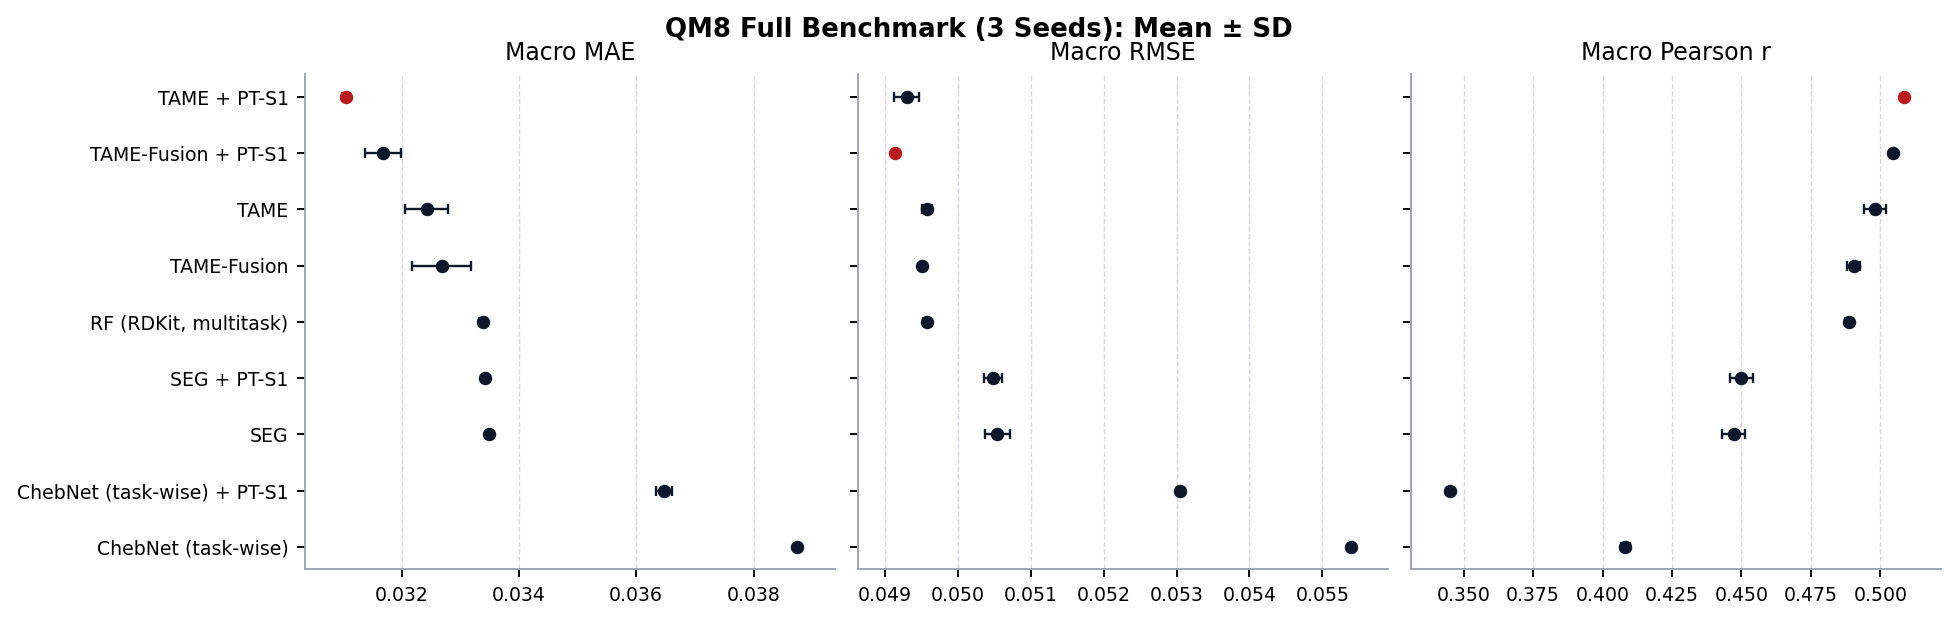

In [7]:
results_dir = workspace_root / 'benchmarking' / 'results'
progress_raw_path = results_dir / 'qm8_full_benchmark_3seed_raw_progress.csv'

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    if progress_raw_path.exists():
        results_df = pd.read_csv(progress_raw_path)
        print(f'Loaded interim results from: {progress_raw_path}')
    else:
        raise RuntimeError(
            'No in-memory results_df and no progress CSV found. Run the benchmark cell first.'
        )

available_seeds = sorted(results_df['seed'].dropna().astype(int).unique().tolist())
print(f'Available seeds in current table: {available_seeds}')
if len(available_seeds) < len(SEEDS):
    print('Note: benchmark seems incomplete; plot shows interim results only.')

summary_df = results_df.groupby('model', as_index=False).agg(
    macro_mae_mean=('macro_mae', 'mean'),
    macro_mae_std=('macro_mae', 'std'),
    macro_rmse_mean=('macro_rmse', 'mean'),
    macro_rmse_std=('macro_rmse', 'std'),
    macro_pearson_mean=('macro_pearson', 'mean'),
    macro_pearson_std=('macro_pearson', 'std'),
    n_tasks_eval_mean=('n_tasks_eval', 'mean'),
    n_runs=('seed', 'nunique'),
)
summary_df = summary_df.sort_values('macro_mae_mean', ascending=True).reset_index(drop=True)
summary_df

label_map = {
    'RF_RDKit_MULTITASK': 'RF (RDKit, multitask)',
    'CHEBNET_TASKWISE_VANILLA': 'ChebNet (task-wise)',
    'CHEBNET_TASKWISE_PRETRAINED_STAGE1': 'ChebNet (task-wise) + PT-S1',
    'SEG_VANILLA': 'SEG',
    'SEG_PRETRAINED_STAGE1': 'SEG + PT-S1',
    'TAME_VANILLA': 'TAME',
    'TAME_PRETRAINED_STAGE1': 'TAME + PT-S1',
    'TAME_FUSION_VANILLA': 'TAME-Fusion',
    'TAME_FUSION_PRETRAINED_STAGE1': 'TAME-Fusion + PT-S1',
}
plot_df = summary_df.copy()
plot_df['label'] = plot_df['model'].map(label_map).fillna(plot_df['model'])

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 0.8,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

y = np.arange(len(plot_df))
y_labels = plot_df['label'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4), sharey=True, constrained_layout=True)
metrics = [
    ('macro_mae_mean', 'macro_mae_std', 'Macro MAE', True),
    ('macro_rmse_mean', 'macro_rmse_std', 'Macro RMSE', True),
    ('macro_pearson_mean', 'macro_pearson_std', 'Macro Pearson r', False),
]

for ax, (m_col, s_col, title, lower_better) in zip(axes, metrics):
    mu = plot_df[m_col].to_numpy(dtype=np.float32)
    sd = plot_df[s_col].fillna(0.0).to_numpy(dtype=np.float32)
    best_idx = int(np.argmin(mu)) if lower_better else int(np.argmax(mu))

    for i in range(len(mu)):
        c = '#0f172a' if i != best_idx else '#b91c1c'
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt='o', markersize=4.7,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.nanmin(mu - sd))
    xmax = float(np.nanmax(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.set_yticks(y, labels=y_labels)
    ax.grid(axis='x', color='#d1d5db', linestyle='--', linewidth=0.6, alpha=0.9)
    ax.grid(axis='y', visible=False)
    ax.invert_yaxis()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9ca3af')
    ax.spines['bottom'].set_color('#9ca3af')

fig.suptitle('QM8 Full Benchmark (3 Seeds): Mean ± SD', y=1.03, fontsize=11, fontweight='bold')

report_img_dir = Path(r'C:\Users\robsc\Nextcloud\Studium\Master Chemie\PC Modul\PC F-Praktikum BASF\PC F-Bericht\images')
report_img_dir.mkdir(parents=True, exist_ok=True)
plot_out = report_img_dir / 'qm8_full_benchmark_3seed.png'
fig.savefig(plot_out, bbox_inches='tight')
print(f'Saved plot: {plot_out}')

plt.show()

In [ ]:
results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

raw_path = results_dir / 'qm8_full_benchmark_3seed_raw.csv'
summary_path = results_dir / 'qm8_full_benchmark_3seed_summary.csv'
plot_data_path = results_dir / 'qm8_full_benchmark_3seed_plotdata.csv'
config_path = results_dir / 'qm8_full_benchmark_3seed_config.json'
history_path = results_dir / 'qm8_full_benchmark_3seed_history.pt'

results_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)
plot_df.to_csv(plot_data_path, index=False)
torch.save(history_bank, history_path)

config_payload = {
    'dataset': 'QM8',
    'task': 'multitask_regression',
    'num_tasks': int(NUM_TASKS),
    'splitter': 'deepchem_molnet_random',
    'split_fractions': None,
    'split_seed': None,
    'seeds': SEEDS,
    'models': [
        'RF_RDKit_MULTITASK',
        'CHEBNET_TASKWISE_VANILLA',
        'CHEBNET_TASKWISE_PRETRAINED_STAGE1',
        'SEG_VANILLA',
        'SEG_PRETRAINED_STAGE1',
        'TAME_VANILLA',
        'TAME_PRETRAINED_STAGE1',
        'TAME_FUSION_VANILLA',
        'TAME_FUSION_PRETRAINED_STAGE1',
    ],
    'artifacts': {
        'raw_results_csv': str(raw_path.name),
        'summary_csv': str(summary_path.name),
        'plot_data_csv': str(plot_data_path.name),
        'history_pt': str(history_path.name),
    },
}
pd.Series(config_payload).to_json(config_path, indent=2)

print(f'Saved raw results: {raw_path.resolve()}')
print(f'Saved summary: {summary_path.resolve()}')
print(f'Saved plot data: {plot_data_path.resolve()}')
print(f'Saved history: {history_path.resolve()}')
print(f'Saved config: {config_path.resolve()}')

Loaded plot data from: progress checkpoint (qm8_full_benchmark_3seed_raw_progress.csv)


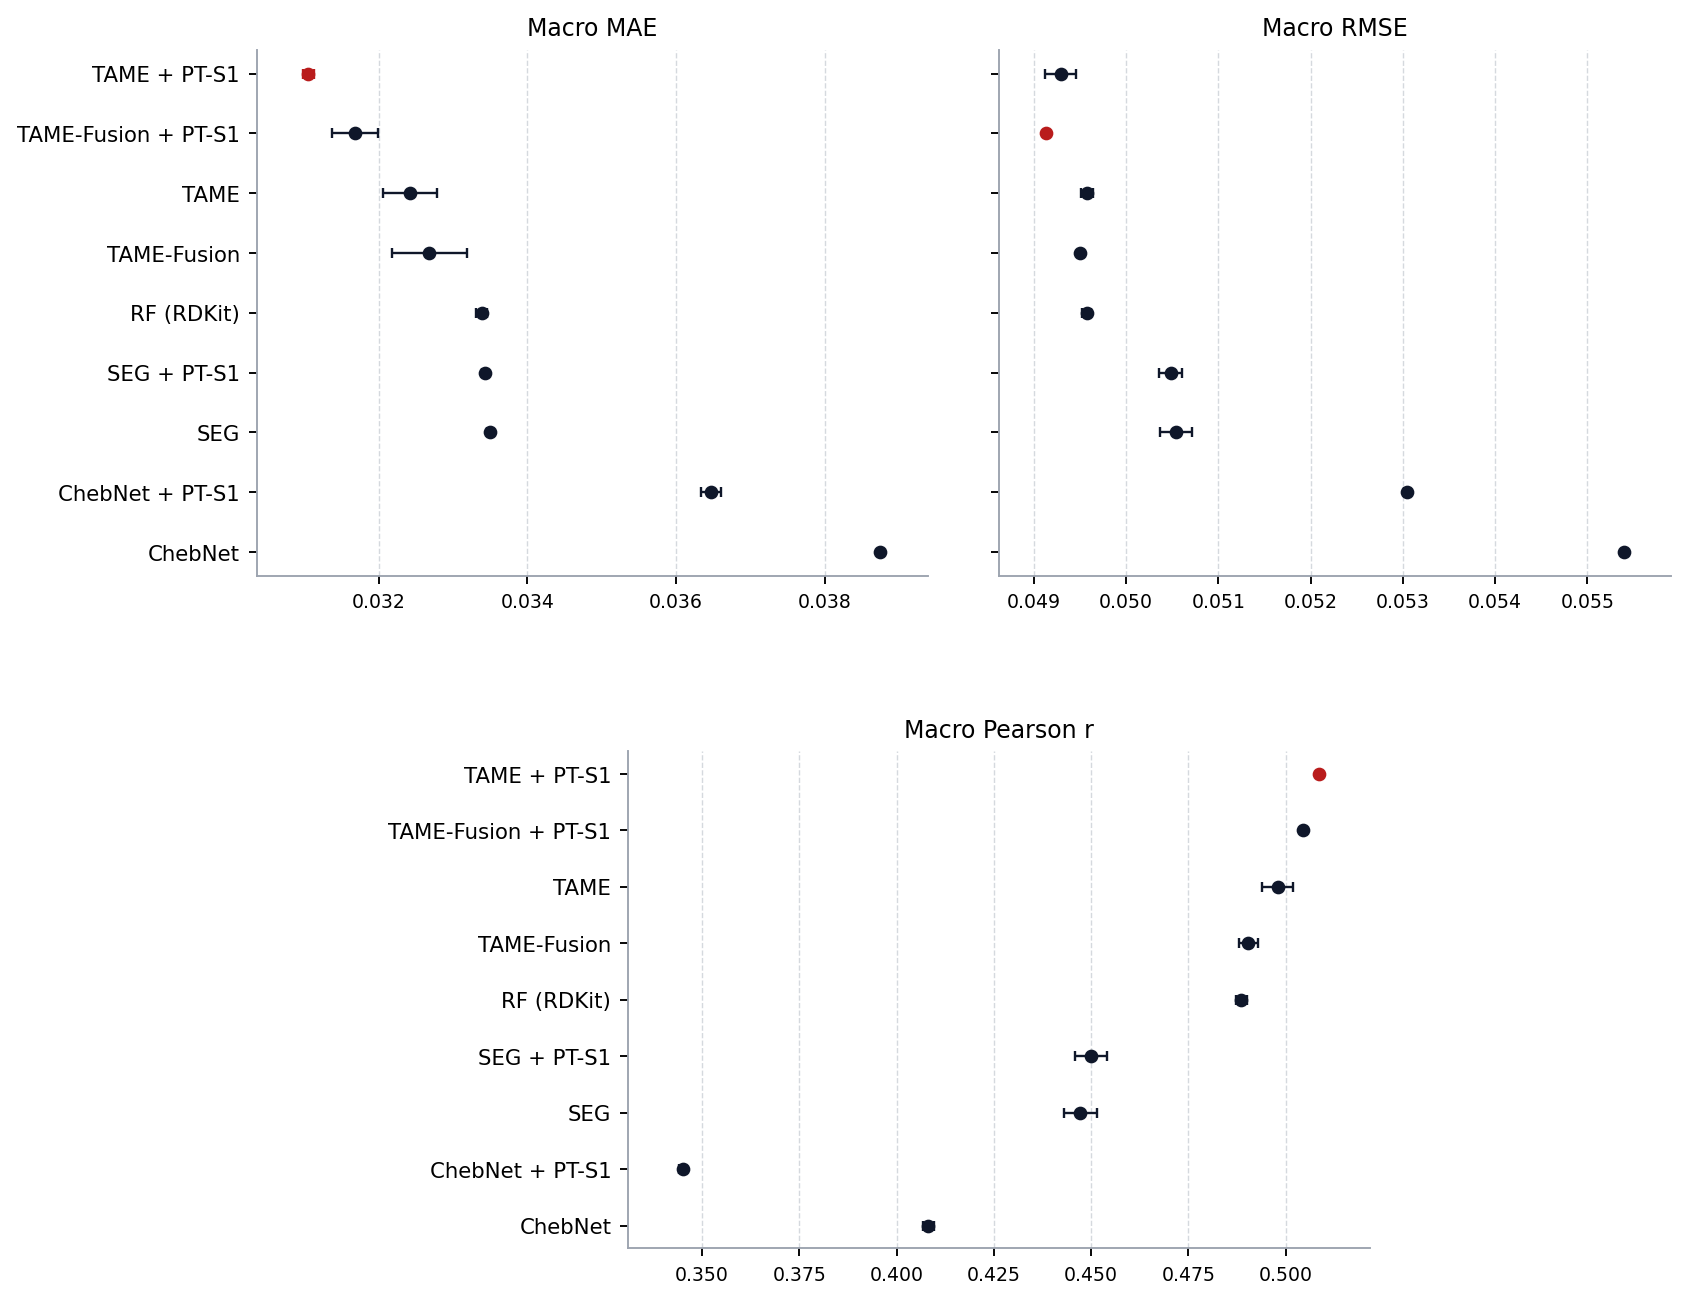

,model,macro_mae_mean,macro_mae_std,macro_rmse_mean,macro_rmse_std,macro_pearson_mean,macro_pearson_std,label
0,TAME_PRETRAINED_STAGE1,0.031053,0.000073,0.049294,0.000167,0.508613,0.000022,TAME + PT-S1
1,TAME_FUSION_PRETRAINED_STAGE1,0.031679,0.000308,0.049133,0.000002,0.504581,0.000484,TAME-Fusion + PT-S1
2,TAME_VANILLA,0.032426,0.000364,0.049577,0.000066,0.498022,0.003963,TAME
3,TAME_FUSION_VANILLA,0.032682,0.000501,0.049505,0.000018,0.490370,0.002469,TAME-Fusion
4,RF_RDKit_MULTITASK,0.033385,0.000070,0.049573,0.000048,0.488632,0.001417,RF (RDKit)
5,SEG_PRETRAINED_STAGE1,0.033424,0.000032,0.050484,0.000122,0.449984,0.004160,SEG + PT-S1
6,SEG_VANILLA,0.033495,0.000038,0.050538,0.000173,0.447171,0.004260,SEG
7,CHEBNET_TASKWISE_PRETRAINED_STAGE1,0.036473,0.000133,0.053046,0.000034,0.344994,0.000937,ChebNet + PT-S1
8,CHEBNET_TASKWISE_VANILLA,0.038749,0.000023,0.055395,0.000007,0.408197,0.001525,ChebNet


In [2]:
# Reload saved QM8 benchmark summary and re-plot in a 2-top / 1-centered-bottom layout.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'benchmarking').exists()), here)

results_dir = workspace_root / 'benchmarking' / 'results'
summary_path = results_dir / 'qm8_full_benchmark_3seed_summary.csv'
progress_raw_path = results_dir / 'qm8_full_benchmark_3seed_raw_progress.csv'
raw_path = results_dir / 'qm8_full_benchmark_3seed_raw.csv'

expected_models = [
    'RF_RDKit_MULTITASK',
    'CHEBNET_TASKWISE_VANILLA',
    'CHEBNET_TASKWISE_PRETRAINED_STAGE1',
    'SEG_VANILLA',
    'SEG_PRETRAINED_STAGE1',
    'TAME_VANILLA',
    'TAME_PRETRAINED_STAGE1',
    'TAME_FUSION_VANILLA',
    'TAME_FUSION_PRETRAINED_STAGE1',
]

summary_cols = [
    'model',
    'macro_mae_mean', 'macro_mae_std',
    'macro_rmse_mean', 'macro_rmse_std',
    'macro_pearson_mean', 'macro_pearson_std',
]

raw_cols = [
    'model', 'seed',
    'macro_mae', 'macro_rmse', 'macro_pearson',
]

def build_summary_from_raw(raw_df):
    missing = [c for c in raw_cols if c not in raw_df.columns]
    if missing:
        raise ValueError(f'Raw fallback file is missing required columns: {missing}')
    return raw_df.groupby('model', as_index=False).agg(
        macro_mae_mean=('macro_mae', 'mean'),
        macro_mae_std=('macro_mae', 'std'),
        macro_rmse_mean=('macro_rmse', 'mean'),
        macro_rmse_std=('macro_rmse', 'std'),
        macro_pearson_mean=('macro_pearson', 'mean'),
        macro_pearson_std=('macro_pearson', 'std'),
    )

summary_plot_df_reload = None
summary_source = None

if summary_path.exists():
    summary_df_candidate = pd.read_csv(summary_path)
    if all(c in summary_df_candidate.columns for c in summary_cols):
        summary_plot_df_reload = summary_df_candidate[summary_cols].copy()
        summary_source = f'summary ({summary_path.name})'

if summary_plot_df_reload is None and progress_raw_path.exists():
    raw_df_candidate = pd.read_csv(progress_raw_path)
    summary_plot_df_reload = build_summary_from_raw(raw_df_candidate)
    summary_source = f'progress checkpoint ({progress_raw_path.name})'

if summary_plot_df_reload is None and raw_path.exists():
    raw_df_candidate = pd.read_csv(raw_path)
    summary_plot_df_reload = build_summary_from_raw(raw_df_candidate)
    summary_source = f'raw ({raw_path.name})'

if summary_plot_df_reload is None:
    raise FileNotFoundError(
        'No usable QM8 result file found. Expected one of: '
        f'{summary_path.name}, {progress_raw_path.name}, {raw_path.name}'
    )

print(f'Loaded plot data from: {summary_source}')

# Keep expected model order availability (partial runs are allowed via fallback files).
summary_plot_df_reload = summary_plot_df_reload[
    summary_plot_df_reload['model'].isin(expected_models)
]

summary_plot_df_reload = summary_plot_df_reload.sort_values('macro_mae_mean', ascending=True).reset_index(drop=True)

label_map_reload = {
    'RF_RDKit_MULTITASK': 'RF (RDKit)',
    'CHEBNET_TASKWISE_VANILLA': 'ChebNet',
    'CHEBNET_TASKWISE_PRETRAINED_STAGE1': 'ChebNet + PT-S1',
    'SEG_VANILLA': 'SEG',
    'SEG_PRETRAINED_STAGE1': 'SEG + PT-S1',
    'TAME_VANILLA': 'TAME',
    'TAME_PRETRAINED_STAGE1': 'TAME + PT-S1',
    'TAME_FUSION_VANILLA': 'TAME-Fusion',
    'TAME_FUSION_PRETRAINED_STAGE1': 'TAME-Fusion + PT-S1',
}
summary_plot_df_reload['label'] = summary_plot_df_reload['model'].map(label_map_reload).fillna(summary_plot_df_reload['model'])

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 400,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 0.8,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 9,
})

y = np.arange(len(summary_plot_df_reload))
y_labels = summary_plot_df_reload['label'].tolist()

fig = plt.figure(figsize=(10.4, 8.6))
ax_mae = fig.add_axes([0.08, 0.56, 0.38, 0.36])
ax_rmse = fig.add_axes([0.50, 0.56, 0.38, 0.36], sharey=ax_mae)
ax_pearson = fig.add_axes([0.29, 0.10, 0.42, 0.34])

axes = [ax_mae, ax_rmse, ax_pearson]
metrics_reload = [
    ('macro_mae_mean', 'macro_mae_std', 'Macro MAE', True),
    ('macro_rmse_mean', 'macro_rmse_std', 'Macro RMSE', True),
    ('macro_pearson_mean', 'macro_pearson_std', 'Macro Pearson r', False),
]

for ax, (m_col, s_col, title, lower_better) in zip(axes, metrics_reload):
    mu = summary_plot_df_reload[m_col].to_numpy(dtype=np.float32)
    sd = summary_plot_df_reload[s_col].fillna(0.0).to_numpy(dtype=np.float32)

    best_idx = int(np.argmin(mu)) if lower_better else int(np.argmax(mu))

    for i in range(len(mu)):
        c = '#0f172a' if i != best_idx else '#b91c1c'
        ax.errorbar(
            mu[i], y[i], xerr=sd[i], fmt='o', markersize=4.8,
            color=c, ecolor=c, elinewidth=1.0, capsize=2, capthick=1.0
        )

    xmin = float(np.min(mu - sd))
    xmax = float(np.max(mu + sd))
    pad = 0.08 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title, pad=6)
    ax.grid(axis='x', color='#d1d5db', linestyle='--', linewidth=0.6, alpha=0.9)
    ax.grid(axis='y', visible=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#9ca3af')
    ax.spines['bottom'].set_color('#9ca3af')

# Invert only once per independent y-axis (avoid double inversion on shared y).
ax_mae.invert_yaxis()
ax_pearson.invert_yaxis()

ax_mae.set_yticks(y, labels=y_labels)
ax_rmse.tick_params(axis='y', labelleft=False)
ax_pearson.set_yticks(y, labels=y_labels)
ax_rmse.set_ylim(ax_mae.get_ylim())

plt.show()

summary_plot_df_reload